In [1]:
import pandas as pd
import os

# Load the dataset
import kagglehub
path = kagglehub.dataset_download("amananandrai/ag-news-classification-dataset")

# List the files in the downloaded path to find the exact CSV name
print("Files in dataset:", os.listdir(path))

# Set the file path with the dataset file name
file_path = os.path.join(path, "test.csv")
df = pd.read_csv(file_path)

# Preview the data
print(df.head())

Using Colab cache for faster access to the 'ag-news-classification-dataset' dataset.
Files in dataset: ['train.csv', 'test.csv']
   Class Index                                              Title  \
0            3                  Fears for T N pension after talks   
1            4  The Race is On: Second Private Team Sets Launc...   
2            4      Ky. Company Wins Grant to Study Peptides (AP)   
3            4      Prediction Unit Helps Forecast Wildfires (AP)   
4            4        Calif. Aims to Limit Farm-Related Smog (AP)   

                                         Description  
0  Unions representing workers at Turner   Newall...  
1  SPACE.com - TORONTO, Canada -- A second\team o...  
2  AP - A company founded by a chemistry research...  
3  AP - It's barely dawn when Mike Fitzpatrick st...  
4  AP - Southern California's smog-fighting agenc...  


In [2]:
# Create the missing column by combining Title and Description
df['full_text'] = df['Title'] + " " + df['Description']

# Check the distribution of the 4 news categories to see if classes are balanced
print(df['Class Index'].value_counts())

# Inspect a random raw entry from the 'full_text' column to see the title/description merge
print(df['full_text'].iloc[1])

Class Index
3    1900
4    1900
2    1900
1    1900
Name: count, dtype: int64
The Race is On: Second Private Team Sets Launch Date for Human Spaceflight (SPACE.com) SPACE.com - TORONTO, Canada -- A second\team of rocketeers competing for the  #36;10 million Ansari X Prize, a contest for\privately funded suborbital space flight, has officially announced the first\launch date for its manned rocket.


In [3]:
# Classifying new articles to categories
df['category_name'] = df['Class Index'].map({1: 'World', 2: 'Sports', 3: 'Business', 4: 'Sci/Tech'})

# Display a sample to confirm the classes
print(df[['Class Index', 'category_name', 'full_text']].head())

   Class Index category_name  \
0            3      Business   
1            4      Sci/Tech   
2            4      Sci/Tech   
3            4      Sci/Tech   
4            4      Sci/Tech   

                                           full_text  
0  Fears for T N pension after talks Unions repre...  
1  The Race is On: Second Private Team Sets Launc...  
2  Ky. Company Wins Grant to Study Peptides (AP) ...  
3  Prediction Unit Helps Forecast Wildfires (AP) ...  
4  Calif. Aims to Limit Farm-Related Smog (AP) AP...  


In [4]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download Lemmatizer resources
nltk.download('wordnet')
nltk.download('omw-1.4')

nltk.download('stopwords')
nltk.download('punkt_tab')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_news(text):
  text = str(text).lower()
  text = re.sub(r'[^a-z\s]', '', text)
  tokenized_text = word_tokenize(text)

  # Lemmatization: Reduces words to their dictionary root
  cleaned = [lemmatizer.lemmatize(w) for w in tokenized_text if w not in stop_words]

  return " ".join(cleaned)

df['cleaned_text'] = df['full_text'].apply(preprocess_news)

# Display the result
print(df[['full_text', 'cleaned_text']].head())


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


                                           full_text  \
0  Fears for T N pension after talks Unions repre...   
1  The Race is On: Second Private Team Sets Launc...   
2  Ky. Company Wins Grant to Study Peptides (AP) ...   
3  Prediction Unit Helps Forecast Wildfires (AP) ...   
4  Calif. Aims to Limit Farm-Related Smog (AP) AP...   

                                        cleaned_text  
0  fear n pension talk union representing worker ...  
1  race second private team set launch date human...  
2  ky company win grant study peptide ap ap compa...  
3  prediction unit help forecast wildfire ap ap b...  
4  calif aim limit farmrelated smog ap ap souther...  


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the vectorizer
tfidf = TfidfVectorizer(max_features=5000)

# Transform the cleaned text into numerical features (X)
X = tfidf.fit_transform(df['cleaned_text'])

# Define our target (y)
y = df['Class Index']

print(f"Vectorization complete. Matrix shape: {X.shape}")

from sklearn.model_selection import train_test_split

# This creates the 4 variables the models are looking for
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Vectorization complete. Matrix shape: (7600, 5000)


In [6]:
from sklearn.linear_model import LogisticRegression

# Initialize and train
log_model = LogisticRegression(max_iter=1000) # Increased iterations for convergence
log_model.fit(X_train, y_train)

print("Logistic Regression training complete.")

Logistic Regression training complete.


In [7]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train
# n_estimators=100 means we are building 100 trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest training complete.")

Random Forest training complete.


In [8]:
from sklearn.svm import SVC

# Initialize and train
# 'linear' kernel is standard for high-dimensional text data
svm_model = SVC(kernel='linear', C=1.0)
svm_model.fit(X_train, y_train)

print("SVM training complete.")

SVM training complete.


In [9]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Note: XGBoost expects labels starting at 0,
# so we subtract 1 from our labels (1,2,3,4 -> 0,1,2,3)
y_train_shifted = y_train - 1

# 1. XGBoost
xgb_model = XGBClassifier()
xgb_model.fit(X_train, y_train_shifted)

# 2. LightGBM
lgbm_model = LGBMClassifier()
lgbm_model.fit(X_train, y_train_shifted)

print("Boosting models trained successfully.")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.049116 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 27339
[LightGBM] [Info] Number of data points in the train set: 6080, number of used features: 1258
[LightGBM] [Info] Start training from score -1.381700
[LightGBM] [Info] Start training from score -1.392233
[LightGBM] [Info] Start training from score -1.372573
[LightGBM] [Info] Start training from score -1.398873
Boosting models trained successfully.


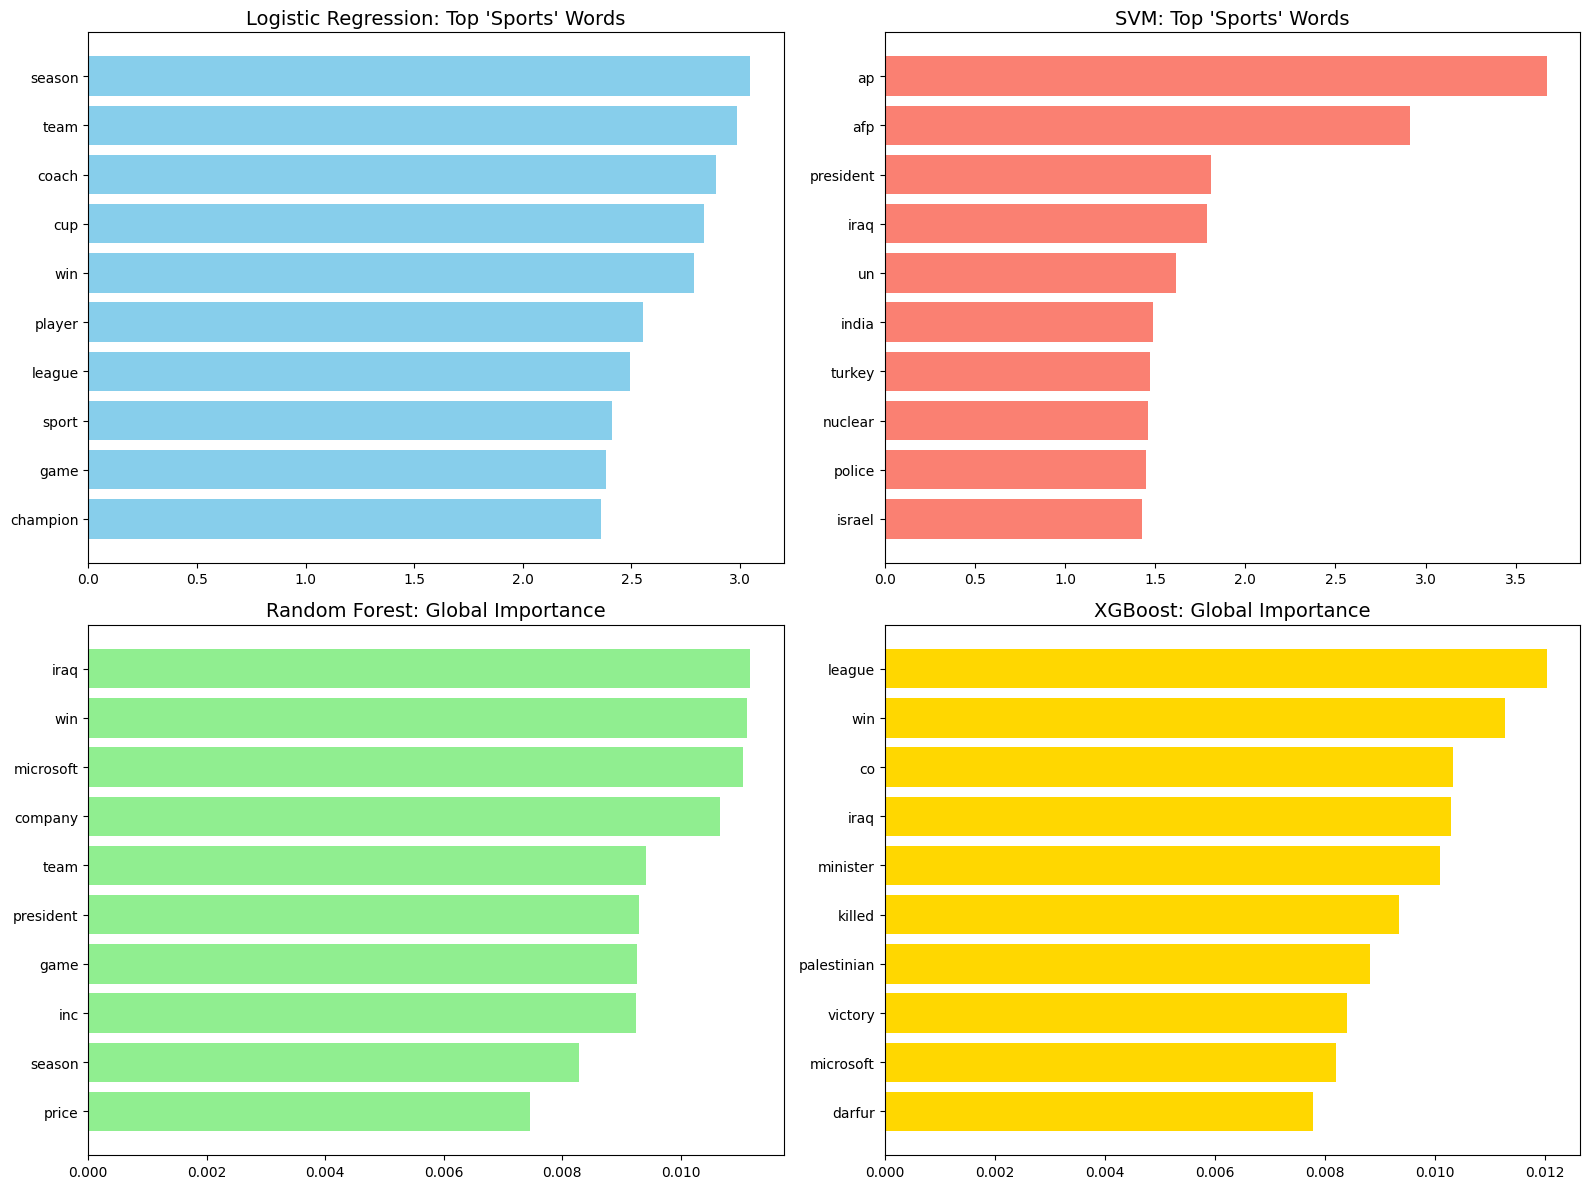

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Create a 2x2 grid for Word Importance
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
feature_names = tfidf.get_feature_names_out()

# --- 1. Logistic Regression (Top words for Sports) ---
log_weights = log_model.coef_[1]
top_log = np.argsort(log_weights)[-10:]
axes[0, 0].barh(feature_names[top_log], log_weights[top_log], color='skyblue')
axes[0, 0].set_title("Logistic Regression: Top 'Sports' Words", fontsize=14)

# --- 2. SVM (Top words for Sports) ---
svm_weights = svm_model.coef_[1].toarray().flatten()
top_svm = np.argsort(svm_weights)[-10:]
axes[0, 1].barh(feature_names[top_svm], svm_weights[top_svm], color='salmon')
axes[0, 1].set_title("SVM: Top 'Sports' Words", fontsize=14)

# --- 3. Random Forest (Global Importance) ---
rf_imp = rf_model.feature_importances_
top_rf = np.argsort(rf_imp)[-10:]
axes[1, 0].barh(feature_names[top_rf], rf_imp[top_rf], color='lightgreen')
axes[1, 0].set_title("Random Forest: Global Importance", fontsize=14)

# --- 4. XGBoost (Global Importance) ---
xgb_imp = xgb_model.feature_importances_
top_xgb = np.argsort(xgb_imp)[-10:]
axes[1, 1].barh(feature_names[top_xgb], xgb_imp[top_xgb], color='gold')
axes[1, 1].set_title("XGBoost: Global Importance", fontsize=14)

plt.tight_layout()
plt.show()

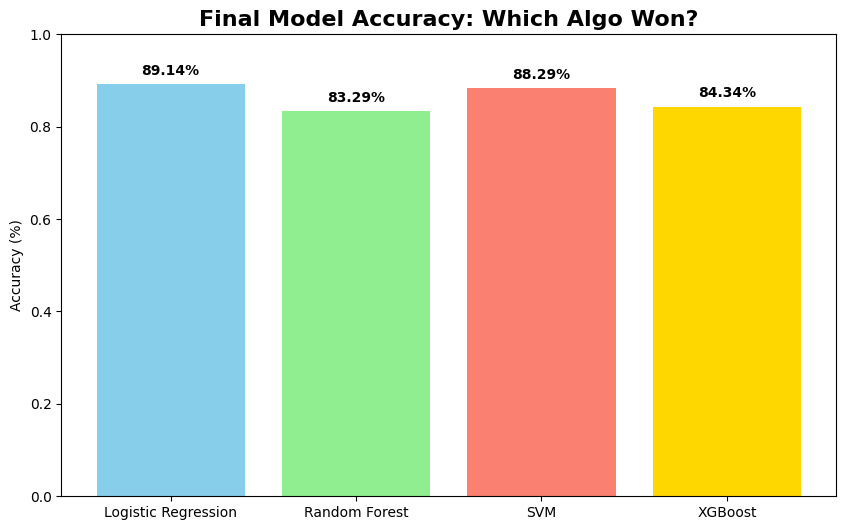

In [13]:
from sklearn.metrics import accuracy_score

y_test_shifted = y_test - 1

# Calculate scores
models = ['Logistic Regression', 'Random Forest', 'SVM', 'XGBoost']
accuracies = [
    accuracy_score(y_test, log_model.predict(X_test)),
    accuracy_score(y_test, rf_model.predict(X_test)),
    accuracy_score(y_test, svm_model.predict(X_test)),
    accuracy_score(y_test_shifted, xgb_model.predict(X_test))
]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=['skyblue', 'lightgreen', 'salmon', 'gold'])
plt.ylim(0, 1.0)
plt.title("Final Model Accuracy: Which Algo Won?", fontsize=16, fontweight='bold')
plt.ylabel("Accuracy (%)")

# Add the percentage labels on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2%}', ha='center', fontweight='bold')

plt.show()

In [14]:
# Training Model using NN

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# 1. One-hot encode the labels (0-indexed)
# AG News has 4 classes, so we subtract 1 and convert to matrix
y_train_nn = to_categorical(y_train - 1, num_classes=4)
y_test_nn = to_categorical(y_test - 1, num_classes=4)

# 2. Convert sparse TF-IDF matrix to dense (required for simple NNs)
X_train_nn = X_train.toarray()
X_test_nn = X_test.toarray()

In [15]:
model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train_nn.shape[1],)),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax') # 4 classes
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 3. Train the model
history = model.fit(X_train_nn, y_train_nn, epochs=5, batch_size=32, validation_split=0.1, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
171/171 ━━━━━━━━━━━━━━━━━━━━ 13s 67ms/step - accuracy: 0.5345 - loss: 1.0847 - val_accuracy: 0.8914 - val_loss: 0.3554
Epoch 2/5
171/171 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.9359 - loss: 0.2134 - val_accuracy: 0.8947 - val_loss: 0.3754
Epoch 3/5
171/171 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.9746 - loss: 0.0830 - val_accuracy: 0.8865 - val_loss: 0.4355
Epoch 4/5
171/171 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.9908 - loss: 0.0327 - val_accuracy: 0.8734 - val_loss: 0.5213
Epoch 5/5
171/171 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.9988 - loss: 0.0101 - val_accuracy: 0.8799 - val_loss: 0.5810


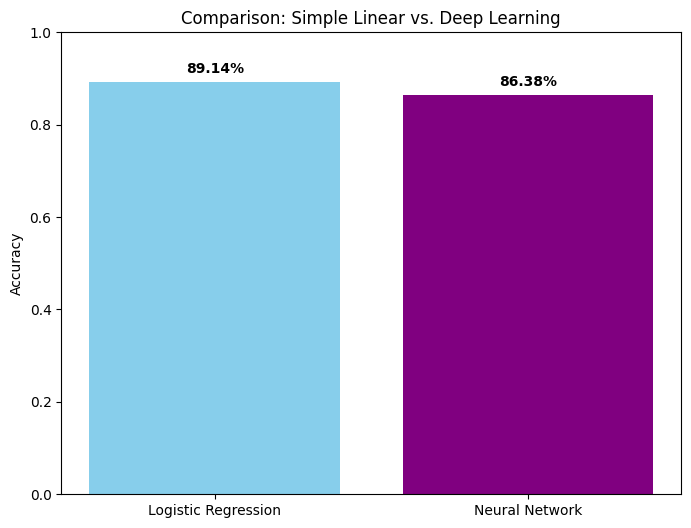

In [16]:
# Get NN accuracy
nn_loss, nn_accuracy = model.evaluate(X_test_nn, y_test_nn, verbose=0)

# Get LogReg accuracy (from our previous step)
log_accuracy = accuracy_score(y_test, log_model.predict(X_test))

# Visualization
plt.figure(figsize=(8, 6))
plt.bar(['Logistic Regression', 'Neural Network'], [log_accuracy, nn_accuracy], color=['skyblue', 'purple'])
plt.ylabel('Accuracy')
plt.title('Comparison: Simple Linear vs. Deep Learning')
plt.ylim(0, 1.0)

# Add text labels
for i, v in enumerate([log_accuracy, nn_accuracy]):
    plt.text(i, v + 0.02, f"{v:.2%}", ha='center', fontweight='bold')

plt.show()

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


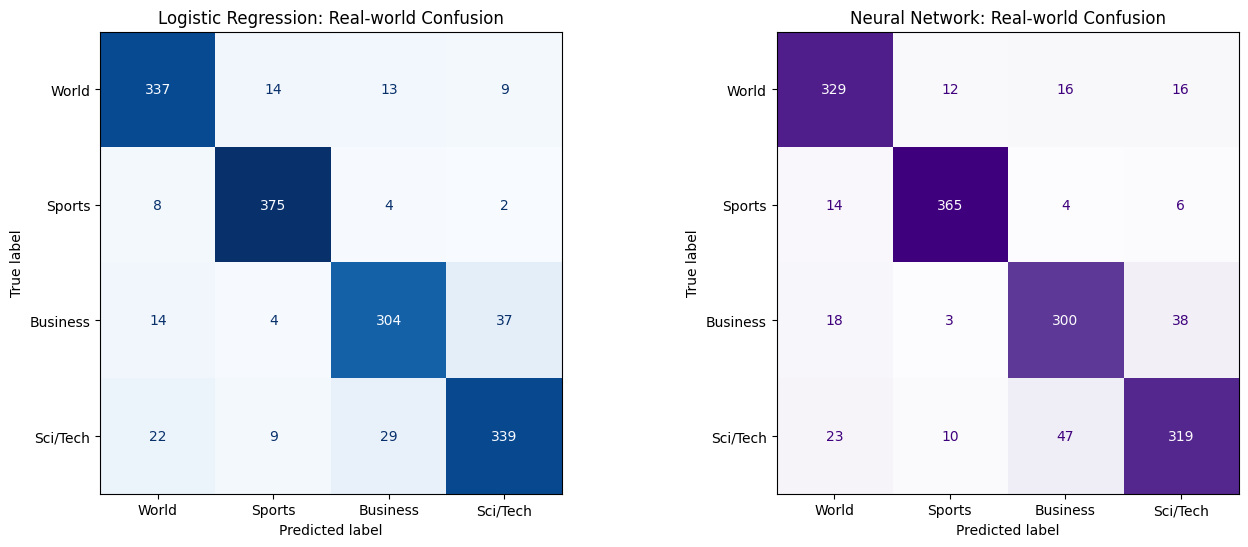

In [17]:
# Confusion matrix to see which is more realistic

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Mapping the Class Index to human-readable names
categories = ['World', 'Sports', 'Business', 'Sci/Tech']

# Get predictions
log_preds = log_model.predict(X_test)
nn_preds = model.predict(X_test_nn).argmax(axis=1) + 1 # Convert back to 1-4 scale

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Logistic Regression Matrix
cm_log = confusion_matrix(y_test, log_preds)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=categories)
disp_log.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title("Logistic Regression: Real-world Confusion")

# Neural Network Matrix
cm_nn = confusion_matrix(y_test, nn_preds)
disp_nn = ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=categories)
disp_nn.plot(ax=axes[1], cmap='Purples', colorbar=False)
axes[1].set_title("Neural Network: Real-world Confusion")

plt.show()